In [1]:
!pip install pandas matplotlib seaborn statsmodels

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset1.csv to dataset1.csv
Saving dataset2.csv to dataset2.csv
Saving dataset3.csv to dataset3.csv


In [3]:
import pandas as pd
dataset1 = pd.read_csv('dataset1.csv')
dataset2 = pd.read_csv('dataset2.csv')
dataset3 = pd.read_csv('dataset3.csv')

In [4]:
# Check columns and missing values
print(dataset1.columns)
print(dataset2.columns)
print(dataset3.columns)

print(dataset1.isnull().sum())
print(dataset2.isnull().sum())
print(dataset3.isnull().sum())

Index(['ID', 'gender', 'minority', 'deprived'], dtype='object')
Index(['ID', 'C_we', 'C_wk', 'G_we', 'G_wk', 'S_we', 'S_wk', 'T_we', 'T_wk'], dtype='object')
Index(['ID', 'Optm', 'Usef', 'Relx', 'Intp', 'Engs', 'Dealpr', 'Thcklr',
       'Goodme', 'Clsep', 'Conf', 'Mkmind', 'Loved', 'Intthg', 'Cheer'],
      dtype='object')
ID          0
gender      0
minority    0
deprived    0
dtype: int64
ID      0
C_we    0
C_wk    0
G_we    0
G_wk    0
S_we    0
S_wk    0
T_we    0
T_wk    0
dtype: int64
ID        0
Optm      0
Usef      0
Relx      0
Intp      0
Engs      0
Dealpr    0
Thcklr    0
Goodme    0
Clsep     0
Conf      0
Mkmind    0
Loved     0
Intthg    0
Cheer     0
dtype: int64


In [5]:
# Merge datasets
merged_data = pd.merge(dataset1, dataset2, on='ID')
merged_data = pd.merge(merged_data, dataset3, on='ID')

print(merged_data.head())
print(merged_data.info())

        ID  gender  minority  deprived  C_we  C_wk  G_we  G_wk  S_we  S_wk  \
0  1087192       0         0         0   2.0   0.5   0.5   0.5   1.0   0.5   
1  1087195       0         0         0   2.0   1.0   0.0   0.0   3.0   1.0   
2  1087205       0         0         0   1.0   0.5   0.0   0.0   0.5   0.5   
3  1087214       0         0         0   2.0   1.0   0.5   0.0   2.0   1.0   
4  1087222       0         0         0   1.0   3.0   0.0   0.0   2.0   1.0   

   ...  Engs  Dealpr  Thcklr  Goodme  Clsep  Conf  Mkmind  Loved  Intthg  \
0  ...     4       4       4       4      5     4       4      5       4   
1  ...     3       4       5       3      5     4       4      5       4   
2  ...     3       3       3       3      4     3       3      3       4   
3  ...     4       4       4       4      3     5       4      5       4   
4  ...     2       3       3       4      4     3       5      5       5   

   Cheer  
0      4  
1      4  
2      4  
3      4  
4      5  

[5 rows

In [6]:
# Generate a summary report
summary_report = {
    "Number of Rows": merged_data.shape[0],
    "Number of Columns": merged_data.shape[1],
    "Columns": merged_data.columns.tolist(),
    "Missing Values": merged_data.isnull().sum().to_dict()
}
print(summary_report)

{'Number of Rows': 98278, 'Number of Columns': 26, 'Columns': ['ID', 'gender', 'minority', 'deprived', 'C_we', 'C_wk', 'G_we', 'G_wk', 'S_we', 'S_wk', 'T_we', 'T_wk', 'Optm', 'Usef', 'Relx', 'Intp', 'Engs', 'Dealpr', 'Thcklr', 'Goodme', 'Clsep', 'Conf', 'Mkmind', 'Loved', 'Intthg', 'Cheer'], 'Missing Values': {'ID': 0, 'gender': 0, 'minority': 0, 'deprived': 0, 'C_we': 0, 'C_wk': 0, 'G_we': 0, 'G_wk': 0, 'S_we': 0, 'S_wk': 0, 'T_we': 0, 'T_wk': 0, 'Optm': 0, 'Usef': 0, 'Relx': 0, 'Intp': 0, 'Engs': 0, 'Dealpr': 0, 'Thcklr': 0, 'Goodme': 0, 'Clsep': 0, 'Conf': 0, 'Mkmind': 0, 'Loved': 0, 'Intthg': 0, 'Cheer': 0}}


In [7]:
merged_data.to_csv('merged_data.csv', index=False)
files.download('merged_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Demographic Distribution (Descriptive Statistical Analyses)

In [9]:
from google.colab import files
uploaded = files.upload()

Saving merged_data.csv to merged_data (1).csv


In [10]:
import pandas as pd

merged_data = pd.read_csv('merged_data.csv')

In [11]:
# Gender distribution analysis
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
gender_distribution = merged_data['gender'].value_counts()
print("Gender Distribution:\n", gender_distribution)


Gender Distribution:
 gender
0    51885
1    46393
Name: count, dtype: int64


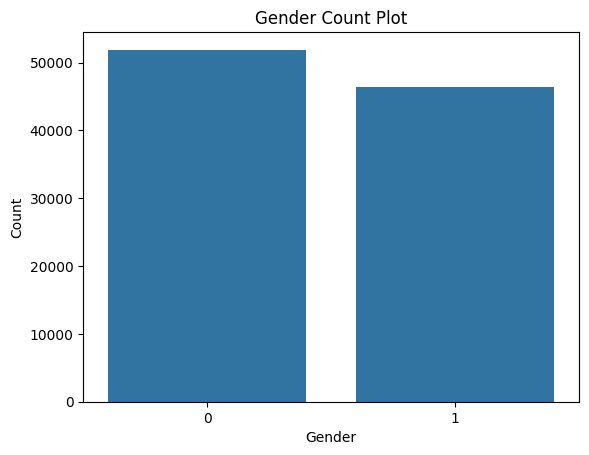

In [15]:
# Visualize gender distribution
sns.countplot(x='gender', data=merged_data)
plt.title('Gender Count Plot')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


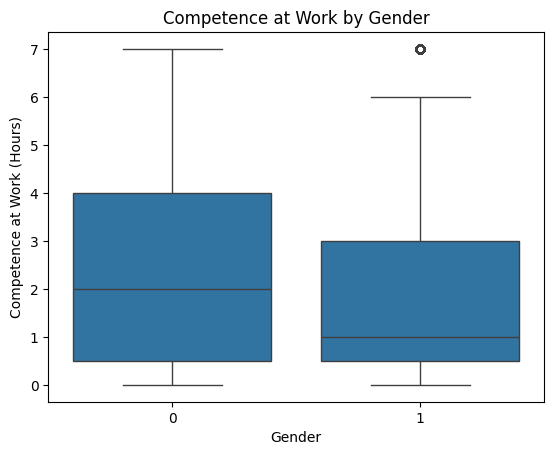

In [16]:
# Boxplot for gender vs 'C_we' (Competence at Work)
sns.boxplot(x='gender', y='C_we', data=merged_data)
plt.title('Competence at Work by Gender')
plt.xlabel('Gender')
plt.ylabel('Competence at Work (Hours)')
plt.show()

In [17]:
# Expanded Descriptive Statistics
gender_summary = merged_data['gender'].describe()
print("Gender Summary:\n", gender_summary)

Gender Summary:
 count    98278.000000
mean         0.472059
std          0.499221
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: gender, dtype: float64


# Behavior and Well-being Scores (Descriptive Statistical Analyses)

In [18]:
# Analyze correlation between Competence at Work (C_we) and General Well-being (G_we)
behavior_correlation = merged_data[['C_we', 'G_we']].corr()
print("Behavior and Well-being Correlation:\n", behavior_correlation)

Behavior and Well-being Correlation:
           C_we      G_we
C_we  1.000000  0.123285
G_we  0.123285  1.000000


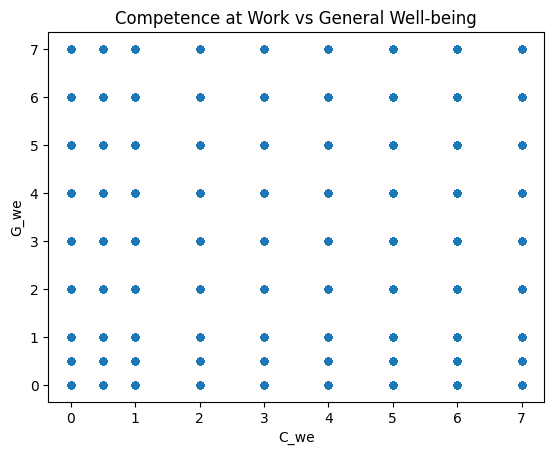

In [19]:
# Scatter plot of Competence at Work vs General Well-being
merged_data.plot(kind='scatter', x='C_we', y='G_we')
plt.title('Competence at Work vs General Well-being')
plt.xlabel('C_we')
plt.ylabel('G_we')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

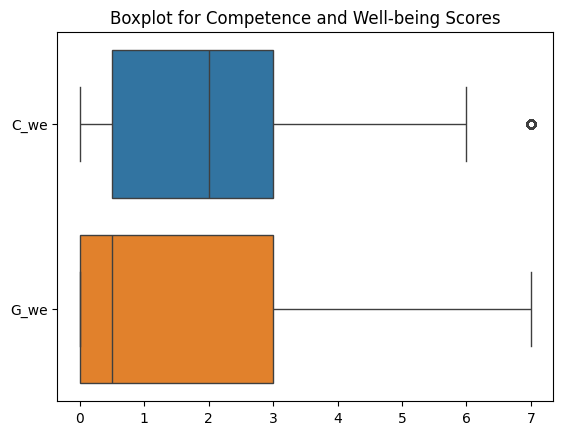

In [20]:
# Expanded summary: Adding boxplots for both variables
sns.boxplot(data=merged_data[['C_we', 'G_we']], orient="h")
plt.title('Boxplot for Competence and Well-being Scores')
plt.show()

In [21]:
# Detailed summary
behavior_summary = merged_data[['C_we', 'G_we']].describe()
print("Behavior and Well-being Summary:\n", behavior_summary)

Behavior and Well-being Summary:
                C_we          G_we
count  98278.000000  98278.000000
mean       2.198483      1.726332
std        2.069802      2.159675
min        0.000000      0.000000
25%        0.500000      0.000000
50%        2.000000      0.500000
75%        3.000000      3.000000
max        7.000000      7.000000


# Gender Differences in Well-being Scores (Inferential Statistical Analyses)

In [22]:
from scipy.stats import mannwhitneyu


In [23]:
male_scores = merged_data[merged_data['gender'] == 1]['Optm']
female_scores = merged_data[merged_data['gender'] == 0]['Optm']

In [24]:
# Mann-Whitney U Test for comparing Optimism scores between genders
u_stat, p_value = mannwhitneyu(male_scores, female_scores)
print(f"Mann-Whitney U Test: U-statistic = {u_stat}, P-value = {p_value}")

Mann-Whitney U Test: U-statistic = 1312884566.5, P-value = 2.608463530697965e-147


In [25]:
if p_value < 0.05:
    print("Significant difference between genders in Optimism scores.")
else:
    print("No significant difference between genders in Optimism scores.")

Significant difference between genders in Optimism scores.


# Correlation Between Optimism and Deprivation (Inferential Statistical Analyses)

In [26]:
import statsmodels.api as sm

In [30]:
threshold = merged_data['Optm'].median()
merged_data['Optm_binary'] = (merged_data['Optm'] >= threshold).astype(int)

In [31]:
# Perform logistic regression with the binary outcome
X = merged_data[['deprived']]
y = merged_data['Optm_binary']
X = sm.add_constant(X)

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.498216
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            Optm_binary   No. Observations:                98278
Model:                          Logit   Df Residuals:                    98276
Method:                           MLE   Df Model:                            1
Date:                Sat, 05 Oct 2024   Pseudo R-squ.:               0.0003661
Time:                        05:30:51   Log-Likelihood:                -48964.
converged:                       True   LL-Null:                       -48982.
Covariance Type:            nonrobust   LLR p-value:                 2.112e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4370      0.011    134.664      0.000       1.416       1.458
deprived      -0.0966      0.

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


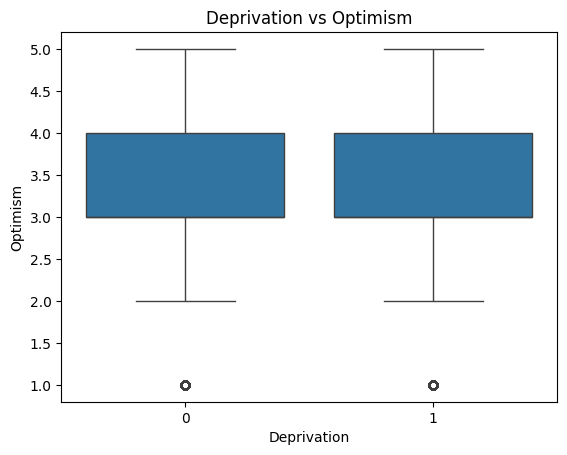

In [32]:
# Visualizing relationship between Deprivation and Optimism
sns.boxplot(x='deprived', y='Optm', data=merged_data)
plt.title('Deprivation vs Optimism')
plt.xlabel('Deprivation')
plt.ylabel('Optimism')
plt.show()

In [33]:
# Coefficient and R-squared explanation
print(f"Coefficient for deprivation: {logit_model.params['deprived']}")
print(f"Pseudo R-squared value: {logit_model.prsquared}")

Coefficient for deprivation: -0.0966486081347847
Pseudo R-squared value: 0.0003661326510475682


In [34]:
# Filtering only continuous variables for heatmap
continuous_vars = merged_data[['C_we', 'G_we', 'Optm', 'deprived']]
correlation_matrix = continuous_vars.corr()

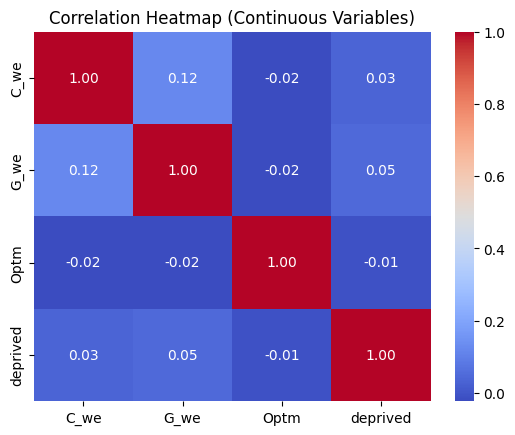

In [35]:
# Heatmap with appropriate continuous variables
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Continuous Variables)')
plt.show()